# RLSS2026 - PG Tutorial: PD Control and Black-Box Optimization (BBO)

Website: https://rlsummerschool.com/

Github repository: https://github.com/araffin/rlss26-pg-tutorial

Slides: https://araffin.github.io/slides/rlss26-bbo-pg/

Gymnasium documentation: https://gymnasium.farama.org/

## Introduction

In this notebook, you will learn about direct policy search using black-box optimization.

We will start from classical control and go towards episodic reinforcement learning to solve the line following problem.

You will implement a simple "bang-bang" controller and then a Proportional-Derivative (PD) controller with hand-tuned gains.
A PD controller can be viewed as a linear policy.

Finally, you will learn to optimize the PD gains automatically using a population based approach (evolution strategy). This approach is the simplest form of episodic RL and serves as a stepping stone to policy gradient algorithms (next notebook).


In [ ]:
# for autoformatting
# !pip install jupyter-black
%load_ext jupyter_black

# for developping
%load_ext autoreload
%autoreload 2

## Install Dependencies

In [ ]:
import os

ON_COLAB = os.environ.get("COLAB_NOTEBOOK_ID") is not None

if ON_COLAB:
    !pip install git+https://github.com/araffin/rlss26-pg-tutorial --upgrade

In [ ]:
if ON_COLAB:
    !apt-get install ffmpeg  # For visualization

## Line Following Environment

For this tutorial, we will use the line following environment where a car try to follow a line to finish a racing track as fast as possible.

<video style="max-width: 70%;" src="https://b2drop.eudat.eu/public.php/dav/files/MDXdmZSfWZPnaXa/line_follow.mp4" controls muted></video>


### Observation space

For this notebook, to follow the line, we will only use the lateral error and previous lateral error. We will include more information in the next notebook (for racing).

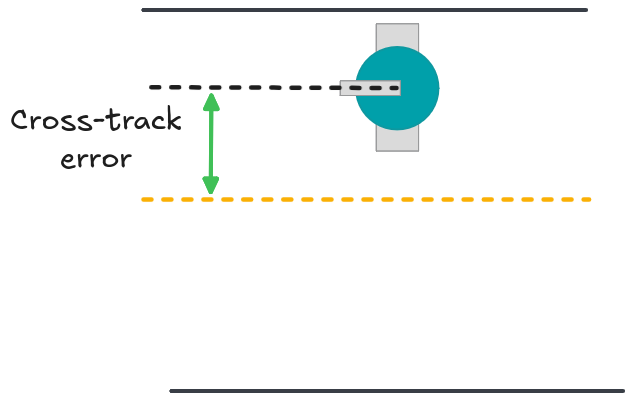


### Action space

To have a simple starting point, we will assume a constant speed and command only the steering (normalized in $[-1, 1]$).

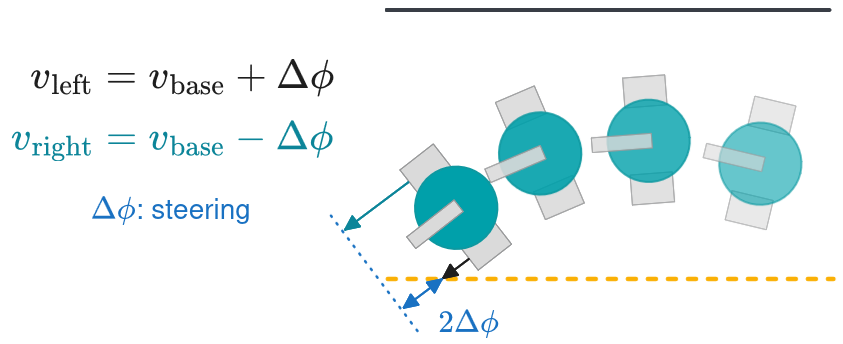


### Reward

The reward function encourages the robot to follow the line while moving forward:
```python
reward = alive_bonus + lateral_penalty + 0.5 * heading_penalty + forward_reward
```

### Termination

The episode terminates when the robot is going off track or going reverse.



In [ ]:
from typing import Callable
import numpy as np

from pg_tutorial.envs.constant_speed import LineFollowerConstantSpeedEnv

# Available tracks: "oval`, "s_track", "rounded_l", "hairpin", "custom".
env = LineFollowerConstantSpeedEnv(track_name="s_track")

In [ ]:
# Box(1) means that there is one continuous action: steering
print("Action space:", env.action_space)

## 1. Exercise (3 minutes): write a simple "bang-bang" controller

A bang-bang controller outputs one of two fixed values depending on the sign of the error:

$$u(t) = M \cdot \text{sign}(e(t)) = \begin{cases} +M & \text{if } e(t) > 0 \\
-M & \text{if } e(t) < 0 \\
0 & \text{if } e(t) = 0 \end{cases}$$

where $e(t)$ is the lateral error and $M$ is the steering step magnitude.

**HINT**: `lateral_error > 0` means we are on the right of the line

**HINT**: `steering > 0` means we are turning left

Note: if you want to test your implementation, there are some tests in the next cell

In [ ]:
from dataclasses import dataclass


@dataclass
class BangBangController:
    steering_step: float = 0.3  # how much to steer when on the left/right of the line

    def compute_action(self, lateral_error: float, prev_lateral_error: float) -> float:
        """
        Compute the steering action to take according to the "bang-bang" control law.

        :param lateral_error: Lateral error to the line (>0 means we are on the right of the line)
        :param prev_lateral_error: Previous lateral error (not used here)
        :return: The steering action (between -1.0 (steer right) and 1.0)
        """
        ### YOUR CODE HERE
        # You need to implement the "bang-bang" control law:
        # - go left when on the right of the line and vice-versa
        # - do nothing when on the line

        if lateral_error > 0:
            # We are on the right of the line, go left
            action = self.steering_step
        elif lateral_error < 0:
            # Go right
            action = -self.steering_step
        else:
            # on the line:
            action = 0.0

        # or in a single line:
        # steering = np.sign(lateral_error) * self.steering_step

        ### END OF YOUR CODE
        return action

    def __call__(self, lateral_error: float, prev_lateral_error: float) -> float:
        # an alias to be able to directly do controller(error, prev_error)
        return self.compute_action(lateral_error, prev_lateral_error)

Let's try the controller:

In [ ]:
STEERING_STEP = 0.5

controller = BangBangController(steering_step=STEERING_STEP)

# sanity checks:
assert controller(lateral_error=0.1, prev_lateral_error=0.0) == STEERING_STEP
assert controller(lateral_error=-0.1, prev_lateral_error=0.0) == -STEERING_STEP
assert controller(lateral_error=0.0, prev_lateral_error=0.0) == 0.0

#### Evaluate and record a video of the bang-bang controller

To evaluate and record a video, we will use the `evaluate` helper that takes the controller and env as input and returns the `best_lap_time` (can be `inf`) and the mean episodic return.

```python
def evaluate(
    controller: Callable,
    env: gym.Env,
    n_eval_episodes: int = 5,
    video_name: str | None = None,
    video_save_path: str | None = None,
    verbose: bool = True,
) -> tuple[float, float]:
    """
    Evaluate a controller on an environment over multiple episodes.

    :param controller: A callable that takes lateral error and previous lateral error as inputs
        and returns an action.
    :param env: The Gymnasium environment to evaluate on.
    :param n_eval_episodes: Number of episodes to evaluate.
    :param video_name: Optional name for recording a video of the evaluation.
    :param video_save_path: Optional directory path to save videos. If None, defaults to the parent
        directory of this file's folder.
    :param verbose: Whether to print evaluation results.
    :return: A tuple containing (best_lap_time, mean_episode_return).
    """
```

In [ ]:
from pathlib import Path

import pg_tutorial
from pg_tutorial.notebook_utils import show_videos
from pg_tutorial.notebook_utils import evaluate

video_save_path = str(Path(pg_tutorial.__file__).parent.parent / "logs" / "videos")

# Available tracks: "oval`, "s_track", "rounded_l", "hairpin", "custom".
eval_env = LineFollowerConstantSpeedEnv(track_name="s_track", base_speed=0.9, render_mode="rgb_array")
video_name = "BANG_BANG"
n_eval_episodes = 2

evaluate(BangBangController(steering_step=0.3), eval_env, n_eval_episodes, video_name=video_name)
show_videos(video_save_path, prefix=video_name)

## 2. Exercise (7 minutes): write a proportional-derivative (PD) controller

A PD controller combines two terms:

$$u(t) = k_p \cdot e(t) + k_d \cdot \frac{d}{dt} e(t)$$

where $k_p$ (proportional gain) and $k_d$ (derivative gain) are the controller parameters.
The proportional term acts like a spring ($F = -k \cdot x$), while the derivative term acts like a damper.

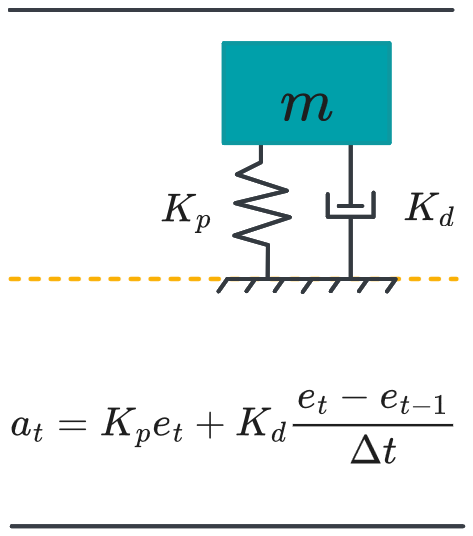



In discrete time, the derivative is approximated using a finite difference:

$$\frac{d}{dt} e(t) \approx \frac{e(t) - e(t-h)}{h}$$

where $h$ is the sampling period ($dt$). The action is clipped to the valid range $[-1, 1]$.

**HINT**: a proportional (P) controller is just like a spring: `action = p_gain * error` (where `p_gain` is usually called `kp`)

**HINT**: a derivative (D) controller is just like a damper: `action = d_gain * derror` (where `derror` is the derivative of the error)

**HINT**: you can approximate the derivative error using `(current - prev) / dt`

Note: if you want to test your implementation, there are some tests in the next cell

In [ ]:
@dataclass
class PDController:
    kp: float = 0.0  # proportional gain
    kd: float = 0.0  # derivative gain
    dt: float = 1 / 60  # controller frequency

    def compute_action(self, lateral_error: float, prev_lateral_error: float) -> float:
        ### YOUR CODE HERE
        # You need to implement the PD control law:
        # it is like a spring-damper system.
        # The proportional part (P controller) just means that we steer proportional to the error
        # The derivative part (D controller) means that we adjust the steering depending on the
        # derivative of the error too.
        # Don't forget to clip the action so that it stays between -1.0 and 1.0

        # Compute the proportional part
        p_steering = self.kp * lateral_error

        # Compute the derivative part, you will need to approximate the derivative of the error
        d_steering = self.kd * (lateral_error - prev_lateral_error) / self.dt

        # Combine the two parts to obtain the PD control law
        action = p_steering + d_steering

        # action = self.kp * lateral_error + self.kd * (lateral_error - prev_lateral_error) / self.dt

        # Don't forget to clip the action so that it falls in the range [-1, 1]
        action = np.clip(action, -1.0, 1.0)
        ### END OF YOUR CODE

        return action

    def __call__(self, lateral_error: float, prev_lateral_error: float) -> float:
        # an alias to be able to directly do controller(error, prev_error)
        return self.compute_action(lateral_error, prev_lateral_error)

You can test the PD controller with the following sanity checks:

In [ ]:
# Test basic PD controller behavior
controller = PDController(kp=1.0, kd=0.0, dt=1 / 60)

# Proportional only test: action should be kp * error
assert np.isclose(controller(lateral_error=0.3, prev_lateral_error=0.0), 0.3)
assert np.isclose(controller(lateral_error=-0.35, prev_lateral_error=0.0), -0.35)
assert controller(lateral_error=0.0, prev_lateral_error=0.0) == 0.0

# Test derivative action (with non-zero kd)
controller = PDController(kp=0.0, kd=60.0, dt=1 / 60)
# Derivative term: kd * (error - prev_error) / dt = 60 * (0.5 - 0.0) / (1/60) = 60 * 0.5 * 60 = 1800
# But this gets clipped to 1.0
assert controller(lateral_error=0.5, prev_lateral_error=0.0) == 1.0

# Smaller derivative input that doesn't clip
controller = PDController(kp=0.0, kd=0.1, dt=1 / 60)
# Derivative term: 0.1 * (0.1 - 0.0) / (1/60) = 0.1 * 0.1 * 60 = 0.6
assert np.isclose(controller(lateral_error=0.1, prev_lateral_error=0.0), 0.6)

# Test action clipping at boundaries
controller = PDController(kp=100.0, kd=100.0, dt=1 / 60)
# Large gains should result in clipped output
assert controller(lateral_error=0.1, prev_lateral_error=0.0) == 1.0
assert controller(lateral_error=-0.1, prev_lateral_error=0.0) == -1.0

# Test with equal errors (zero derivative)
controller = PDController(kp=0.5, kd=1.0, dt=1 / 60)
assert np.isclose(controller(lateral_error=0.5, prev_lateral_error=0.5), 0.25)  # only kp contributes

#### Evaluate and record a video of the PD controller

Play with the gains (`kp`, `kd`) to see the effect and try to have a good controller.

Note: you can make the evaluation faster by passing `video_name=None`

In [ ]:
# Available tracks: "oval`, "s_track", "rounded_l", "hairpin", "custom".
eval_env = LineFollowerConstantSpeedEnv(
    track_name="s_track",
    base_speed=0.5,
    render_mode="rgb_array",
    max_episode_steps=500,  # reduce the max number of steps to reduce RAM usage when creating the video
)
video_name = "pd_controller"
n_eval_episodes = 1

evaluate(PDController(kp=0.01, kd=0.01, dt=eval_env.dt), eval_env, n_eval_episodes, video_name=video_name)
# tuned gains:
# evaluate(PDController(kp=0.00555, kd=0.00709, dt=env.dt), eval_env, n_eval_episodes, video_name=video_name)
show_videos(video_save_path, prefix=video_name)

## 3. Exercise (10 minutes): Optimize the gains automatically using black-box optimization (BBO)

To optimize the gains of the PD controller, we will implement a simple $(1 + \lambda)$ evolution strategy (ES), a population based algorithm.

The algorithm maintains a best parameter vector $\theta^*$ and generates $\lambda$ offspring around it by adding Gaussian noise:

$$\theta^{(i)} = \theta^* + \mathcal{N}(0, \sigma^2 I) \quad \text{for } i = 1, \dots, \lambda$$

Then selects the best-performing candidate as the new parent (here, we will also include the parent in the candidates):

$$\theta^* \leftarrow \text{argmin}_{\theta' \in \{\theta^{(1)}, \dots, \theta^{(\lambda)}, \theta^*\}} J(\theta')$$

In our case, $\theta = (k_p, k_d)$ are the PD gains and $J(\theta)$ is the best lap time (lower is better).

The algorithm loop is:
1. sample a population of $\lambda$ candidates (`pop_size`) around the best known parameters (Gaussian noise added to the parameters)
2. evaluate the population of candidate
3. keep the best candidate so far (best known parameters)
4. repeat

**HINT**: Lower lap time is better. The objective is to minimize `best_lap_time`.  The `evaluate` function returns `[best_lap_time, mean_reward]`.

**Note**: Play with `pop_size`, `pop_std`, and `n_iterations`. Larger population gives more exploration but slower iterations.

Note: run the BBO cell below to observe the optimization in action.

In [ ]:
def display_gains(gains: np.ndarray) -> str:
    """A small helper to have cleaner print for the PD gains"""
    kp, kd = gains
    return f"{kp=:.5f}, {kd=:.5f}"

In [ ]:
# Optimize gains with BBO
# Available tracks: "oval`, "s_track", "rounded_l", "hairpin", "custom".
eval_env = LineFollowerConstantSpeedEnv(
    track_name="s_track",
    base_speed=0.5,
    max_episode_steps=800,
)
n_eval_episodes = 2

# Initial PD gains (the parameters we are optimizing)
initial_kp = initial_kd = 0.0001
best_gains = np.array([initial_kp, initial_kd])
# Number of random candidates to generate per iteration
pop_size = 5
# Standard deviation of Gaussian noise added to best_gains to create candidates
pop_std = 0.001
# Number of optimization iterations
n_iterations = 10

### YOUR CODE HERE
# TODO:
# 1. Evaluate the initial policy to initialize best_lap_time (our objective)

# Initialize best_lap_time by evaluating the initial gains
best_lap_time, _ = evaluate(
    PDController(kp=initial_kp, kd=initial_kd, dt=eval_env.dt),
    eval_env,
    n_eval_episodes,
    verbose=False,
)
# alternative: best_lap_time = float("inf")
# optional: seed the pseudo random generator for reproducibility
# np.random.seed(2026)
### END OF YOUR CODE

for iteration in range(1, n_iterations + 1):
    ### YOUR CODE HERE
    # TODO:
    # 1. Generate candidate parameters by adding Gaussian noise to the best_gains
    # 2. Evaluate each candidate in the environment and keep the best one (or keep the parent)
    # 3. (Optional) Decay the noise std over time (`pop_std`) to reduce exploration
    #
    # NOTE: negative gains don't make sense so clip to 0
    candidates = np.maximum(0, best_gains + np.random.normal(0.0, pop_std, size=(pop_size, 2)))
    # for candidate in candidates:
    # for _ in range(pop_size):
    #    kp = np.maximum(0, best_kp + np.random.normal(0.0, pop_std))
    #    kd = np.maximum(0, best_kd + np.random.normal(0.0, pop_std))
    for kp, kd in candidates:

        # Evaluate the candidate gains
        lap_time, _ = evaluate(
            PDController(kp=kp, kd=kd, dt=eval_env.dt),
            eval_env,
            n_eval_episodes,
            verbose=False,
        )
        # Keep the best candidate so far (lower lap time is better)
        if lap_time < best_lap_time:
            best_lap_time = lap_time
            best_gains = np.array([kp, kd])
    # optional: std decay to reduce exploration over time
    # pop_std = pop_std * 0.99

    ### END OF YOUR CODE

    print(f"{iteration=:02d} | {best_lap_time=:.2f}s | {display_gains(best_gains)}")

You can test the tuned gains here:

In [ ]:
# Available tracks: "oval`, "s_track", "rounded_l", "hairpin", "custom".
eval_env = LineFollowerConstantSpeedEnv(
    track_name="s_track",
    base_speed=0.5,
    render_mode="rgb_array",
    max_episode_steps=500,  # reduce the max number of steps to reduce RAM usage when creating the video
)
video_name = "pd_controller_tuned_bbo"
n_eval_episodes = 1

# Update kp, kd with the tuned gains
evaluate(PDController(kp=0.01, kd=0.01, dt=eval_env.dt), eval_env, n_eval_episodes, video_name=video_name)
show_videos(video_save_path, prefix=video_name)

## 4. [Bonus] Exercise: Optimize the gains automatically using finite-difference

Another way to optimize the gains of the PD controller is to approximate the gradient of the objective function using finite-differences (we're getting close to policy gradient).

**HINT**: Finite-difference approximates the gradient by perturbing each parameter symmetrically $$\text{grad} \approx (J(\theta + \epsilon) - J(\theta - \epsilon)) \cdot \mathbf{u}$$
    where $\mathbf{u}$ is the direction of the perturbation (unit vector) and $\epsilon$ is the magnitude of the perturbation

**HINT**: Compare convergence with BBO. Finite-difference typically converges faster per iteration but can be noisier depending on the `epsilon` and `n_deltas`.

**HINT**: The ARS trick (`grad /= reward_std`) normalizes the gradient by reward standard deviation to stabilize training. Try disabling it to see the difference.

Note: run the finite-difference cell below to observe the optimization in action.

In [ ]:
# Optimize gains with finite diff
# Available tracks: "oval`, "s_track", "rounded_l", "hairpin", "custom".
eval_env = LineFollowerConstantSpeedEnv(
    track_name="s_track",
    base_speed=0.5,
    max_episode_steps=800,
)
n_eval_episodes = 2

# Initial PD gains (the parameters we are optimizing)
initial_kp = initial_kd = 0.0001
gains = np.array([initial_kp, initial_kd])
# best_gains = (initial_kp, initial_kd)
# Number of random directions to sample per gradient estimation step
n_deltas = 5
# Magnitude of the perturbation (central difference)
epsilon = 0.0001
# Number of optimization iterations
n_iterations = 10
# Track the best lap time found so far (for display purposes)
best_lap_time = float("inf")
# Step size for the gradient ascent update
learning_rate = 0.001

for iteration in range(1, n_iterations + 1):
    # Initialize the gradient
    grad = np.zeros_like(gains)
    rewards = []
    ### YOUR CODE HERE
    # TODO:
    # 1. Sample a random direction and normalize it (unit vector)
    # 2. For each random direction, perturb the gains in + and - directions (central difference)
    # 3. Evaluate both perturbed controllers and accumulate the gradient estimate
    # 4. Normalize the gradient and update the gains (gradient ascent: maximize reward)
    #
    # The central-difference formula approximates the gradient as:
    #   grad += (J(theta + eps * direction) - J(theta - eps * direction)) * direction
    for _ in range(n_deltas):
        # Choose a random direction (you can use `np.random.normal` or `np.random.uniform`)
        direction = np.random.normal(size=2)
        # Normalize the direction so that we have a unit vector (you can use np.linalg.norm())
        direction /= np.linalg.norm(direction)

        # Perturb the current gains in the sampled direction (in both +/- epsilon)
        # Make sure to have positive gains (you can use `np.maximum()` for that or use the log trick)
        gains_plus = np.maximum(0, gains + epsilon * direction)
        gains_minus = np.maximum(0, gains - epsilon * direction)

        # Evaluate the two candidates (lap_time, reward = evaluate(PDController(kp=..., kd=...))
        # We will use the reward for computing the gradient, the lap time is just to display some info
        lap_time_plus, reward_plus = evaluate(
            PDController(kp=gains_plus[0], kd=gains_plus[1], dt=eval_env.dt),
            eval_env,
            n_eval_episodes,
            verbose=False,
        )
        lap_time_minus, reward_minus = evaluate(
            PDController(kp=gains_minus[0], kd=gains_minus[1], dt=eval_env.dt),
            eval_env,
            n_eval_episodes,
            verbose=False,
        )
        # Track best lap time for display (not used for gradient)
        if lap_time_plus < best_lap_time:
            best_lap_time = lap_time_plus
        if lap_time_minus < best_lap_time:
            best_lap_time = lap_time_minus

        # Accumulate the gradient estimate using central difference:
        # grad += (J(theta + eps * u) - J(theta - eps * u)) * u
        grad += (reward_plus - reward_minus) * direction
        # Note: we skip the scaling factor 1 / (2 * epsilon) otherwise we need to rescale the lr
        # or clip the gradient norm
        rewards.extend([reward_plus, reward_minus])

    # Average the gradient over n_deltas random directions
    grad /= n_deltas
    # ARS trick: normalize by reward std (stabilizes training)
    reward_std = np.std(rewards) + 1e-6  # avoid division by zero
    grad /= reward_std

    # Update the gains by following the gradient direction (gradient ascent: maximize reward)
    # Make sure the gains are positive (we could also use the log trick)
    gains = np.maximum(0.0, gains + learning_rate * grad)

    ### END OF YOUR CODE

    mean_reward = np.mean(rewards).item()

    print(f"{iteration=:02d} | {mean_reward=:.2f} | {best_lap_time=:.2f}s | {display_gains(gains)}")

In [ ]:
# Available tracks: "oval`, "s_track", "rounded_l", "hairpin", "custom".
eval_env = LineFollowerConstantSpeedEnv(
    track_name="s_track",
    base_speed=0.5,
    render_mode="rgb_array",
    max_episode_steps=500,  # reduce the max number of steps to reduce RAM usage when creating the video
)
video_name = "pd_controller_tuned_fd"
n_eval_episodes = 1

# Update kp, kd with the tuned gains
evaluate(PDController(kp=0.01, kd=0.01, dt=eval_env.dt), eval_env, n_eval_episodes, video_name=video_name)
show_videos(video_save_path, prefix=video_name)

### Going further

- play with the different hyperparameters
- use the log trick instead of numpy clipping (`np.maximum()`) to keep the gains positive
- implement a variant of the FD algorithm (using forward diff $J(\theta + \epsilon) - J(\theta)$ instead of the central diff)
- Combine the lateral error PD with a heading error PD (`evaluate()` method need to be rewritten)
- replace the PD controller with a linear policy
- implement another BBO approach (random search, grid search, swarm optimization, ...)

## Conclusion

What we have seen in this notebook:
- following a line using bang-bang controller
- following a line using a linear policy (PD controller)
- optimizing the gains automatically using black-box optimization (episodic RL)